Assigment Module 1

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [4]:
shapefile = '/Users/farabiisa/Downloads/REGIONE_LOMBARDIA_2020/Comuni_2020_poligonali.shp'
comuni = gpd.GeoDataFrame.from_file(shapefile)
comuni

,CLASSREF,BELFIORE,COD_ISTATN,NOME_COM,COD_PRO,NOME_PRO,SIG_PRO,COD_CMO,NOME_CMO,COD_ASL,...,ANNO,ISTAT,LEGGE_ISTI,ATS_COD,ATS_DEC,CMETR_COD,CMETR_DEC,SHAPE_AREA,SHAPE_LEN,geometry
0,0570159f-0e0f-4edd-824c-23388d03a009,I276,03018144,SANT`ANGELO LOMELLINA,18,PAVIA,PV,None,None,12,...,0,18144,None,030328,ATS DI PAVIA,None,None,1.039710e+07,16920.894524,"POLYGON ((473246.942 5007601.023, 473219.08 50..."
1,560529b7-af1e-4dee-a47b-8dd8541bc6b6,D367,03015101,DRESANO,15,MILANO,MI,None,None,10,...,0,15101,None,030321,ATS DELLA CITTA' METROPOLITANA DI MILANO,001,CITTA' METROPOLITANA DI MILANO,3.505868e+06,9639.637073,"POLYGON ((527474.56 5024855.804, 527522.56 502..."
2,f3df939e-5fb6-4ccb-b040-bcfc0ee5b550,E608,03018082,LIRIO,18,PAVIA,PV,None,None,12,...,0,18082,None,030328,ATS DI PAVIA,None,None,1.801643e+06,6545.893954,"POLYGON ((520442.619 4983554.516, 520455.695 4..."
3,1274f1c9-79a2-40a4-8e4b-9e18bb967257,A849,03108009,BIASSONO,108,MONZA E DELLA BRIANZA,MB,None,None,11,...,0,108009,None,030324,ATS DELLA BRIANZA,None,None,4.793857e+06,16331.735972,"POLYGON ((521794.699 5052163.025, 521708.324 5..."
4,2eb51e8c-a2ce-418d-ba5e-ec32d2b3f219,L778,03017196,VEROLAVECCHIA,17,BRESCIA,BS,None,None,2,...,0,17196,None,030326,ATS DI BRESCIA,None,None,2.105491e+07,33160.467156,"POLYGON ((583283.59 5014246.553, 583277.806 50..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1501,fe5b9f49-0505-4d8f-b73e-b3a7e10c0e37,C014,03015060,CASSINA DE PECCHI,15,MILANO,MI,None,None,10,...,0,15060,None,030321,ATS DELLA CITTA' METROPOLITANA DI MILANO,001,CITTA' METROPOLITANA DI MILANO,7.070506e+06,17667.580037,"POLYGON ((528708.395 5041461.67, 528725.645 50..."
1502,8d59f56a-40ec-40a3-bb7a-58e72fe2f9cc,L115,03012126,TERNATE,12,VARESE,VA,None,None,14,...,0,12126,None,030322,ATS DELL'INSUBRIA,None,None,4.806990e+06,10923.525906,"POLYGON ((477662.95 5071290.28, 477655.8 50712..."
1503,701c4634-f460-4aa5-9d41-074c4d85f4d7,H760,03013204,SAN BARTOLOMEO VAL CAVARGNA,13,COMO,CO,ZO16,VALLI DEL LARIO E DEL CERESIO,3,...,0,13204,None,030322,ATS DELL'INSUBRIA,None,None,1.055159e+07,18470.015263,"POLYGON ((511297.948 5102180.335, 511296.073 5..."
1504,f55a7a8b-7563-43b2-b12f-658e9b997bcc,G889,03013189,PORLEZZA,13,COMO,CO,ZO16,VALLI DEL LARIO E DEL CERESIO,3,...,0,13189,None,030322,ATS DELL'INSUBRIA,None,None,1.902149e+07,24473.450557,"POLYGON ((512470.245 5095391.447, 512469.245 5..."


In [6]:
tab_pop = pd.read_csv('/Users/farabiisa/Downloads/Lombardia_Pop2011_2014.csv', sep=',', encoding='unicode_escape')
tab_pop

,Codice,Comune,Cod_prov,Provincia,Pop2011,Pop2014
0,3017064,CORZANO,17,BRESCIA,1358.0,1427.0
1,3017167,RUDIANO,17,BRESCIA,5861.0,5822.0
2,3017201,VILLANUOVA SUL CLISI,17,BRESCIA,5855.0,5778.0
3,3017084,IRMA,17,BRESCIA,152.0,128.0
4,3017102,MANERBA DEL GARDA,17,BRESCIA,4985.0,5290.0
...,...,...,...,...,...,...
1526,3012043,CASTELLO CABIAGLIO,12,VARESE,548.0,582.0
1527,3012062,CUVEGLIO,12,VARESE,3443.0,3428.0
1528,3012037,CASALZUIGNO,12,VARESE,1360.0,1336.0
1529,3012038,CASCIAGO,12,VARESE,3916.0,3841.0


In [7]:
tab_pop.rename(columns={'Codice': 'COD_ISTATN'}, inplace=True)

In [8]:
tab_pop['COD_ISTATN'] = tab_pop['COD_ISTATN'].astype(int)
comuni['COD_ISTATN'] = comuni['COD_ISTATN'].astype(int)

In [9]:
comuni = comuni.merge(tab_pop, on='COD_ISTATN')

In [11]:
comuni_milano = comuni[comuni['NOME_PRO'] == 'MILANO'].copy()

In [21]:
comuni_milano['area_km2'] = comuni_milano.geometry.area / 1e6

In [22]:
comuni_milano['density_2014'] = comuni_milano['Pop2014'] / comuni_milano['area_km2']

In [23]:
comuni_milano

,CLASSREF,BELFIORE,COD_ISTATN,NOME_COM,COD_PRO,NOME_PRO,SIG_PRO,COD_CMO,NOME_CMO,COD_ASL,...,SHAPE_AREA,SHAPE_LEN,geometry,Comune,Cod_prov,Provincia,Pop2011,Pop2014,area_km2,density_2014
1,560529b7-af1e-4dee-a47b-8dd8541bc6b6,D367,3015101,DRESANO,15,MILANO,MI,None,None,10,...,3.505868e+06,9639.637073,"POLYGON ((527474.56 5024855.804, 527522.56 502...",DRESANO,15,MILANO,2992.0,3085.0,3.505868,879.953392
6,b8e130e3-27c4-4d8e-8150-9d4033f3968d,F939,3015155,NOSATE,15,MILANO,MI,None,None,9,...,4.923317e+06,10882.729418,"POLYGON ((477387.977 5043229.079, 477367.102 5...",NOSATE,15,MILANO,689.0,684.0,4.923317,138.930728
26,bffbe2c0-3c38-448f-8727-ac65c0a1e62b,C565,3015074,CESANO BOSCONE,15,MILANO,MI,None,None,9,...,3.968097e+06,13732.359584,"POLYGON ((505892.397 5030623.348, 505871.397 5...",CESANO BOSCONE,15,MILANO,23935.0,23535.0,3.968097,5931.054445
28,12b046b2-595d-457e-aae7-146d4ae1b187,I361,3015200,SANTO STEFANO TICINO,15,MILANO,MI,None,None,9,...,5.029254e+06,13713.349991,"POLYGON ((491591.146 5037520.98, 491622.77 503...",SANTO STEFANO TICINO,15,MILANO,4731.0,5013.0,5.029254,996.768084
35,e16e79e2-a44e-418e-8fdd-556d03a2636e,B240,3015036,BUCCINASCO,15,MILANO,MI,None,None,9,...,1.199857e+07,27089.543783,"POLYGON ((506778.868 5029702.921, 506781.303 5...",BUCCINASCO,15,MILANO,26937.0,27123.0,11.998566,2260.520136
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1427,bb11d32a-8905-4929-af5d-b017424b1cf4,I415,3015202,SAN ZENONE AL LAMBRO,15,MILANO,MI,None,None,10,...,7.246165e+06,20966.223118,"POLYGON ((530259.53 5017081.445, 530253.279 50...",SAN ZENONE AL LAMBRO,15,MILANO,4193.0,4335.0,7.246165,598.247525
1447,b6088ec4-f10b-447d-8160-66048242bfd0,H803,3015191,SAN COLOMBANO AL LAMBRO,15,MILANO,MI,None,None,6,...,1.657445e+07,28572.596552,"POLYGON ((541803.47 5001429.362, 541770.734 50...",SAN COLOMBANO AL LAMBRO,15,MILANO,7468.0,7399.0,16.574451,446.409963
1467,a7cc231a-c770-4a18-8097-c0779f700aa3,I577,3015205,SEGRATE,15,MILANO,MI,None,None,10,...,1.730485e+07,27156.910466,"POLYGON ((521289.675 5034309.649, 521284.575 5...",SEGRATE,15,MILANO,34352.0,34908.0,17.304851,2017.237881
1471,23b5ee2e-bbae-4c93-833c-dea79add4365,I690,3015209,SESTO SAN GIOVANNI,15,MILANO,MI,None,None,8,...,1.176890e+07,21720.086973,"POLYGON ((521208.165 5044838.643, 521206.665 5...",SESTO SAN GIOVANNI,15,MILANO,81130.0,81490.0,11.768900,6924.181519


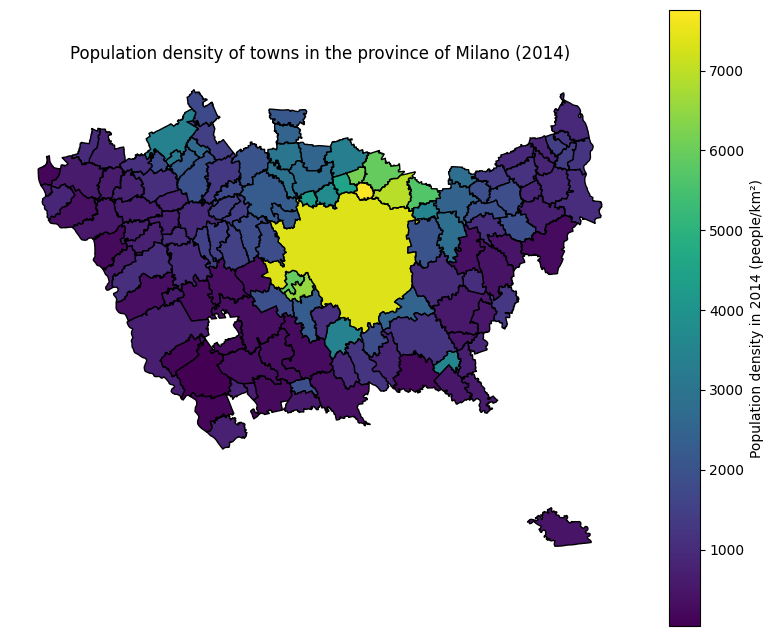

In [24]:
ax = comuni_milano.plot(column='density_2014', cmap='viridis', legend=True, 
                        edgecolor='black', figsize=(10, 8), legend_kwds={'label': 'Population density in 2014 (people/km²)'})

ax.set_title('Population density of towns in the province of Milano (2014)')
ax.set_axis_off()

plt.show()